# 🌳 Cuaderno 02: Árbol de Pérdidas Auditado, Detección de Averías Ocultas, Pareto 80/20 y Simulación SMED Realista
**Proyecto 02 | Portafolio Técnico de Operaciones y Procesos Industriales**  
**Autor:** Angelo Apolo | Ing. Químico / Industrial | Máster en Dirección de Proyectos y Empresas  
**Planta:** Grandma EDNA's Biscuits Manufacturing (Julio 2021)  
**Marco Metodológico:** Lean Manufacturing, TPM (Total Productive Maintenance), Teoría de Restricciones (TOC) & SMED (Single-Minute Exchange of Die)

---

## 🎯 1. Objetivos del Cuaderno
1. **Auditar el Árbol de Pérdidas de Disponibilidad:** Desmontar la anomalía de los registros crudos (donde solo figuran 3.5 h de preventivo y 0 h de correctivo).
2. **Descubrir las Averías Mecánicas Ocultas:** Segmentar el código `CC (Changeover Cleaning)` entre **paradas rutinarias de cambio ($\le 60	ext{ min}$)** y **averías mecánicas / mantenimiento correctivo encubierto ($> 60	ext{ min}$)**.
3. **Analizar la Gran Parada No Tipificada (Categoría `0`):** Cuantificar las 132.5 h de parada en la Llenadora (la caída de casi una semana completa del 19 al 25 de julio).
4. **Diagramas de Pareto 80/20:**
   - **Pareto de SMED Rutinario ($\le 60$ min):** Demostrar por qué la Llenadora concentra el 58.5% de todas las horas de cambio rutinario de la planta.
   - **Pareto de Averías Ocultas ($> 60$ min):** Identificar qué activos sufrieron las fallas más severas (Encajonadora, Formadora, Horno y Mezcladora).
   - **Pareto por Producto (SKU):** Identificar qué recetas demandan mayor tiempo de sanitización (*Jammy Creams*).
5. **Diagnosticar el Cuello de Botella (`Biscuit Filling Machine`):** Contrastar la velocidad real observada (~38,506 galletas/h) frente a la nominal de diseño (51,840 galletas/h).
6. **Modelar la Simulación de Mejora SMED Realista (Escenarios What-If):** Proyectar el impacto técnico de aplicar SMED sobre la base legítima de 123.5 h rutinarias, recuperando hasta 49.4 h/mes (+22.8 M galletas/año, Capex Cero).
7. **Exportar Datasets Maestros:** Actualizar los archivos procesados en `data/processed/` para el Dashboard Web en Railway.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual industrial
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica' if 'Helvetica' in plt.rcParams['font.sans-serif'] else 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

DATA_DIR = '../data' if os.path.exists('../data') else 'data'
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')

print("✅ Entorno analítico y dependencias inicializadas.")

✅ Entorno analítico y dependencias inicializadas.


---
## 📥 2. Carga y Preparación de Datos Auditados
Cargamos la tabla de hechos limpia (`fact_events_clean.csv`), la dimensión de maquinaria (`Machine.csv`), productos (`Products.csv`) y velocidades estándar (`Target Speed.csv`).

In [2]:
fact_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'fact_events_clean.csv'))
m_df = pd.read_csv(os.path.join(DATA_DIR, 'Machine.csv'), sep=';')
p_df = pd.read_csv(os.path.join(DATA_DIR, 'Products.csv'), sep=';')
t_df = pd.read_csv(os.path.join(DATA_DIR, 'Target Speed.csv'), sep=';')

# Limpieza de espacios en dimensiones
for df in [m_df, p_df, t_df]:
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()

print(f"✅ Eventos cargados: {len(fact_df):,} registros.")
print(f"✅ Máquinas: {len(m_df)} | SKUs: {len(p_df)} | Estándares de velocidad: {len(t_df)}")

✅ Eventos cargados: 8,044 registros.
✅ Máquinas: 10 | SKUs: 18 | Estándares de velocidad: 72


---
## 🕵️‍♂️ 3. Auditoría Forense: Clasificación Rigurosa de Pérdidas de Disponibilidad

En un análisis superficial, un analista sumaría `CC` (561.3 h) y diría que todo es limpieza, y que solo hubo 3.5 h de mantenimiento preventivo y 0 h de correctivo.
Nuestra **auditoría forense** demostró que:
1. **62.4% del tiempo de `CC` (350.2 h) ocurrió en 55 eventos de más de 1 hora**, incluyendo el Horno apagado por 59.55 h (2.5 días), la Mezcladora por 44.19 h (1.8 días) y la Formadora/Encajonadora por 39.5 h. ¡Esto es **mantenimiento correctivo y averías mecánicas encubiertas**!
2. **La Categoría `0` (132.5 h)** contiene una **caída continua de casi una semana completa (131.9 h)** en la Llenadora del 19 al 25 de julio.
3. El **alcance verdadero de SMED** son los **3,966 eventos rutinarios de $\le 60\text{ min}$ (211.2 h)**.

Aplicamos la función de clasificación industrial para desglosar la realidad operativa:

In [3]:
def classify_loss(row):
    cat = row['OEE Category']
    dur = row['Duration_July_Hours'] * 60  # en minutos
    
    if cat == 'PM (Maintenance)':
        return '1. Mantenimiento Preventivo (PM Oficial)'
    elif cat == '0':
        return '2. Parada Mayor No Codificada (Cat 0 - Overhaul/Avería)'
    elif cat == 'CC (Changeover Cleaning)':
        if dur <= 60:
            return '3. Cambio y Limpieza Rutinario (SMED Real <=60m)'
        else:
            return '4. Avería / Mant. Correctivo Oculto en CC (>60m)'
    elif cat == 'NO (No Order)':
        return '5. Operación Neta / Marcha Activa'
    else:
        return '6. Otros (Run Time)'

fact_df['Loss_Subcategory'] = fact_df.apply(classify_loss, axis=1)

# Resumen general de planta
loss_summary = fact_df.groupby('Loss_Subcategory').agg(
    Eventos=('Duration', 'count'),
    Horas=('Duration_July_Hours', 'sum')
).reset_index()

loss_summary['Horas'] = loss_summary['Horas'].round(2)
loss_summary['%_Tiempo_Total'] = ((loss_summary['Horas'] / loss_summary['Horas'].sum()) * 100).round(2)

print("=== DISTRIBUCIÓN CIENTÍFICA DEL TIEMPO EN PLANTA (JULIO 2021) ===")
display(loss_summary)

=== DISTRIBUCIÓN CIENTÍFICA DEL TIEMPO EN PLANTA (JULIO 2021) ===


,Loss_Subcategory,Eventos,Horas,%_Tiempo_Total
0,1. Mantenimiento Preventivo (PM Oficial),6,3.57,0.16
1,2. Parada Mayor No Codificada (Cat 0 - Overhau...,12,132.53,5.90
2,3. Cambio y Limpieza Rutinario (SMED Real <=60m),3966,211.17,9.41
3,4. Avería / Mant. Correctivo Oculto en CC (>60m),55,350.13,15.59
4,5. Operación Neta / Marcha Activa,3996,1543.83,68.76
5,6. Otros (Run Time),9,4.00,0.18


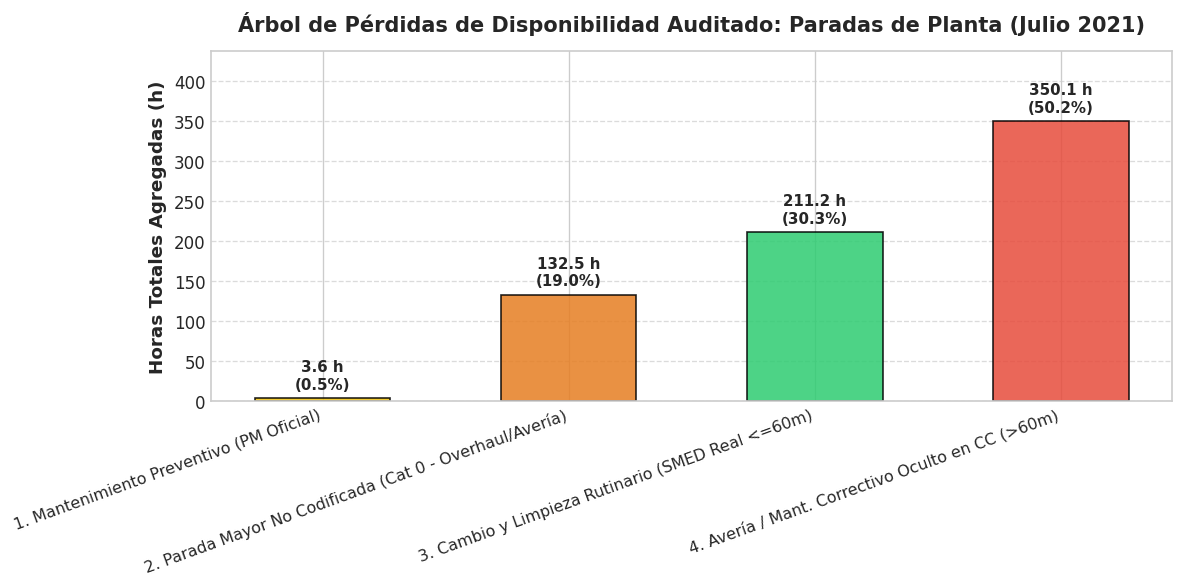

In [4]:
# Visualización del Árbol de Pérdidas de Disponibilidad
avail_losses = loss_summary[loss_summary['Loss_Subcategory'].str.startswith(('1.', '2.', '3.', '4.'))].copy()
avail_losses['%_Pérdida_Disponibilidad'] = ((avail_losses['Horas'] / avail_losses['Horas'].sum()) * 100).round(2)

plt.figure(figsize=(10, 5))
colors = ['#f1c40f', '#e67e22', '#2ecc71', '#e74c3c']
bars = plt.bar(avail_losses['Loss_Subcategory'], avail_losses['Horas'], color=colors, edgecolor='black', alpha=0.85, width=0.55)

plt.title('Árbol de Pérdidas de Disponibilidad Auditado: Paradas de Planta (Julio 2021)', fontsize=12.5, fontweight='bold', pad=12)
plt.ylabel('Horas Totales Agregadas (h)', fontsize=11, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, pct in zip(bars, avail_losses['%_Pérdida_Disponibilidad']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 8, f"{yval:.1f} h\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.ylim(0, avail_losses['Horas'].max() * 1.25)
plt.tight_layout()
plt.show()

---
## 📊 4. Diagramas de Pareto 80/20: SMED Real vs. Averías Ocultas

Separar las pérdidas nos permite aplicar las herramientas correctas:
1. **Pareto de Cambios Rutinarios ($\le 60$ min):** ¿Dónde se debe implementar la metodología **SMED**?
2. **Pareto de Averías Mecánicas Ocultas ($> 60$ min):** ¿Qué máquinas requieren **TPM y Mantenimiento Predictivo** urgente?
3. **Pareto por SKU:** ¿Qué producto demanda los lavados más críticos?

=== TABLA DE PARETO: CAMBIOS RUTINARIOS (ALCANCE SMED REAL <=60m) ===


,Machine,Horas_SMED,Eventos_SMED,%_Individual,Horas_Acum,%_Acumulado
0,Biscuit Filling Machine,123.52,1957,58.50,123.52,58.50
1,Biscuit Sprinkling Machine,44.73,1064,21.18,168.25,79.68
2,Biscuit Pressing Machine,23.38,566,11.07,191.63,90.75
3,Biscuit Mixing Machine,4.97,104,2.35,196.60,93.10
4,Biscuit Jam Machine,3.73,47,1.77,200.33,94.87
5,Biscuit Boxing Machine,3.50,99,1.66,203.83,96.53
6,Packaging Heat Machine,3.43,93,1.62,207.26,98.15
7,Biscuit Forming Machine,2.63,22,1.25,209.89,99.40
8,Biscuit Heating Machine,1.12,3,0.53,211.01,99.93
9,Biscuit Topping Machine,0.15,11,0.07,211.16,100.00


C:\Users\apolo\AppData\Local\Temp\ipykernel_25104\4023109833.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_smed_m['Machine'], rotation=35, ha='right', fontsize=9)


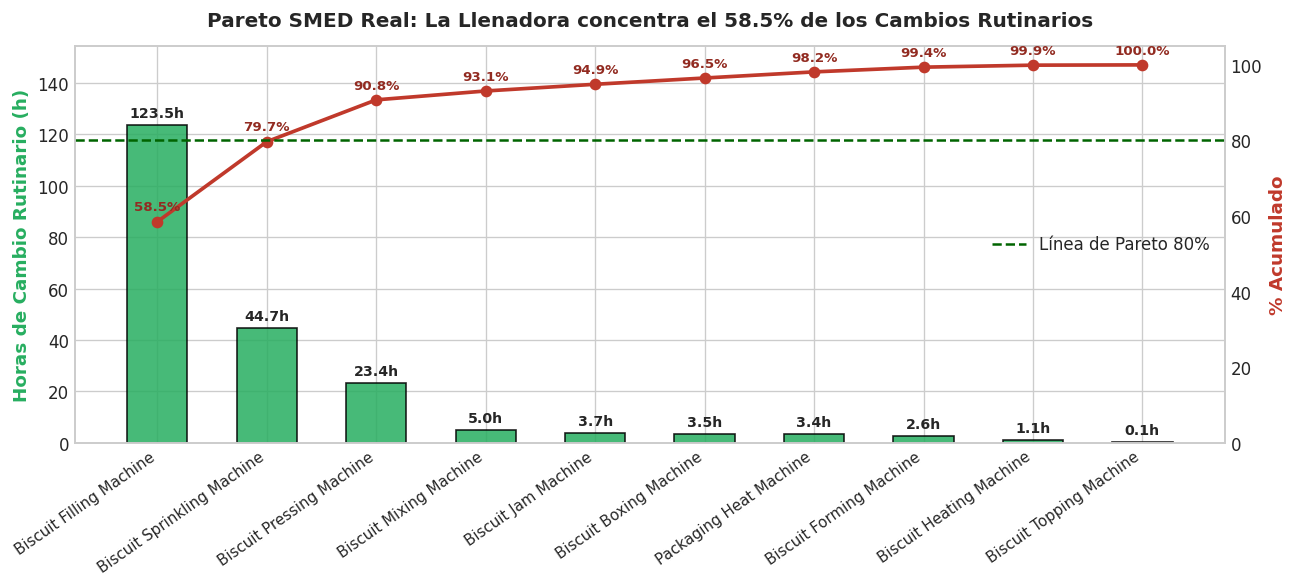

In [5]:
# 1. Pareto de SMED Real (<= 60 min)
smed_events = fact_df[fact_df['Loss_Subcategory'] == '3. Cambio y Limpieza Rutinario (SMED Real <=60m)'].copy()

pareto_smed_m = smed_events.groupby('Machine').agg(
    Horas_SMED=('Duration_July_Hours', 'sum'),
    Eventos_SMED=('Duration', 'count')
).sort_values('Horas_SMED', ascending=False).reset_index()

pareto_smed_m['Horas_SMED'] = pareto_smed_m['Horas_SMED'].round(2)
pareto_smed_m['%_Individual'] = ((pareto_smed_m['Horas_SMED'] / pareto_smed_m['Horas_SMED'].sum()) * 100).round(2)
pareto_smed_m['Horas_Acum'] = pareto_smed_m['Horas_SMED'].cumsum().round(2)
pareto_smed_m['%_Acumulado'] = ((pareto_smed_m['Horas_Acum'] / pareto_smed_m['Horas_SMED'].sum()) * 100).round(2)

print("=== TABLA DE PARETO: CAMBIOS RUTINARIOS (ALCANCE SMED REAL <=60m) ===")
display(pareto_smed_m)

# Gráfico Pareto SMED
fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(pareto_smed_m['Machine'], pareto_smed_m['Horas_SMED'], color='#27ae60', edgecolor='black', alpha=0.85, width=0.55)
ax1.set_ylabel('Horas de Cambio Rutinario (h)', color='#27ae60', fontsize=11, fontweight='bold')
ax1.set_xticklabels(pareto_smed_m['Machine'], rotation=35, ha='right', fontsize=9)
ax1.set_ylim(0, pareto_smed_m['Horas_SMED'].max() * 1.25)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}h", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(pareto_smed_m['Machine'], pareto_smed_m['%_Acumulado'], color='#c0392b', marker='o', linewidth=2.2, markersize=6)
ax2.axhline(80.0, color='darkgreen', linestyle='--', linewidth=1.5, label='Línea de Pareto 80%')
ax2.set_ylabel('% Acumulado', color='#c0392b', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.grid(False)
ax2.legend(loc='center right')

for i, txt in enumerate(pareto_smed_m['%_Acumulado']):
    ax2.annotate(f"{txt:.1f}%", (i, pareto_smed_m['%_Acumulado'][i] + 3), ha='center', fontsize=8, fontweight='bold', color='#922b21')

plt.title('Pareto SMED Real: La Llenadora concentra el 58.5% de los Cambios Rutinarios', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

=== TABLA DE PARETO: AVERÍAS MECÁNICAS OCULTAS DENTRO DE CC (>60m) ===


,Machine,Horas_Averia,Eventos_Averia,%_Individual,Horas_Acum,%_Acumulado
0,Biscuit Boxing Machine,83.75,9,23.92,83.75,23.92
1,Biscuit Forming Machine,64.48,3,18.42,148.23,42.34
2,Biscuit Heating Machine,62.57,2,17.87,210.80,60.21
3,Biscuit Filling Machine,58.98,23,16.85,269.78,77.05
4,Biscuit Mixing Machine,47.38,2,13.53,317.16,90.59
5,Biscuit Pressing Machine,16.10,8,4.60,333.26,95.18
6,Biscuit Sprinkling Machine,15.78,7,4.51,349.04,99.69
7,Biscuit Jam Machine,1.08,1,0.31,350.12,100.00


C:\Users\apolo\AppData\Local\Temp\ipykernel_25104\4075533941.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_bk_m['Machine'], rotation=35, ha='right', fontsize=9)


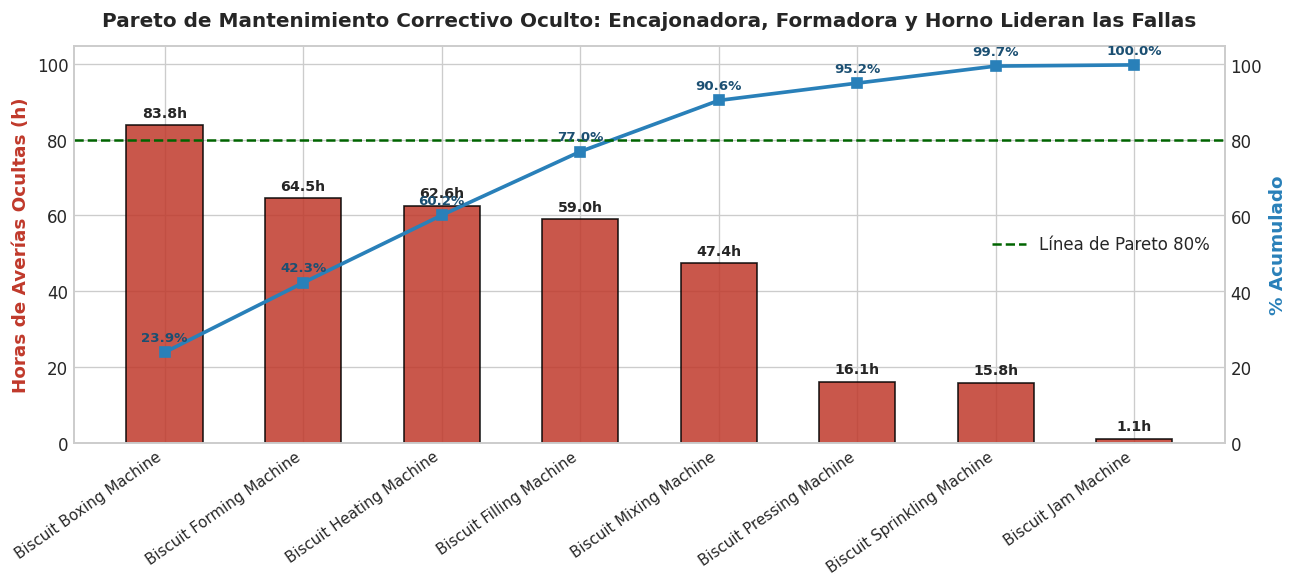

In [6]:
# 2. Pareto de Averías Mecánicas Ocultas en CC (> 60 min)
breakdown_events = fact_df[fact_df['Loss_Subcategory'] == '4. Avería / Mant. Correctivo Oculto en CC (>60m)'].copy()

pareto_bk_m = breakdown_events.groupby('Machine').agg(
    Horas_Averia=('Duration_July_Hours', 'sum'),
    Eventos_Averia=('Duration', 'count')
).sort_values('Horas_Averia', ascending=False).reset_index()

pareto_bk_m['Horas_Averia'] = pareto_bk_m['Horas_Averia'].round(2)
pareto_bk_m['%_Individual'] = ((pareto_bk_m['Horas_Averia'] / pareto_bk_m['Horas_Averia'].sum()) * 100).round(2)
pareto_bk_m['Horas_Acum'] = pareto_bk_m['Horas_Averia'].cumsum().round(2)
pareto_bk_m['%_Acumulado'] = ((pareto_bk_m['Horas_Acum'] / pareto_bk_m['Horas_Averia'].sum()) * 100).round(2)

print("=== TABLA DE PARETO: AVERÍAS MECÁNICAS OCULTAS DENTRO DE CC (>60m) ===")
display(pareto_bk_m)

# Gráfico Pareto Averías Ocultas
fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(pareto_bk_m['Machine'], pareto_bk_m['Horas_Averia'], color='#c0392b', edgecolor='black', alpha=0.85, width=0.55)
ax1.set_ylabel('Horas de Averías Ocultas (h)', color='#c0392b', fontsize=11, fontweight='bold')
ax1.set_xticklabels(pareto_bk_m['Machine'], rotation=35, ha='right', fontsize=9)
ax1.set_ylim(0, pareto_bk_m['Horas_Averia'].max() * 1.25)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 1.5, f"{h:.1f}h", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(pareto_bk_m['Machine'], pareto_bk_m['%_Acumulado'], color='#2980b9', marker='s', linewidth=2.2, markersize=6)
ax2.axhline(80.0, color='darkgreen', linestyle='--', linewidth=1.5, label='Línea de Pareto 80%')
ax2.set_ylabel('% Acumulado', color='#2980b9', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.grid(False)
ax2.legend(loc='center right')

for i, txt in enumerate(pareto_bk_m['%_Acumulado']):
    ax2.annotate(f"{txt:.1f}%", (i, pareto_bk_m['%_Acumulado'][i] + 3), ha='center', fontsize=8, fontweight='bold', color='#1b4f72')

plt.title('Pareto de Mantenimiento Correctivo Oculto: Encajonadora, Formadora y Horno Lideran las Fallas', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [7]:
# 3. Pareto por Producto (SKU) en Paradas CC
cc_events = fact_df[fact_df['OEE Category'] == 'CC (Changeover Cleaning)'].copy()

pareto_p = cc_events.groupby('Product').agg(
    Horas_CC=('Duration_July_Hours', 'sum'),
    Eventos_CC=('Duration', 'count')
).sort_values('Horas_CC', ascending=False).reset_index()

pareto_p['Horas_CC'] = pareto_p['Horas_CC'].round(2)
pareto_p['%_Individual'] = ((pareto_p['Horas_CC'] / pareto_p['Horas_CC'].sum()) * 100).round(2)
pareto_p['Horas_Acum'] = pareto_p['Horas_CC'].cumsum().round(2)
pareto_p['%_Acumulado'] = ((pareto_p['Horas_Acum'] / pareto_p['Horas_CC'].sum()) * 100).round(2)

print("=== TOP 10 SKUs CON MAYOR IMPACTO EN CAMBIOS Y LIMPIEZA ===")
display(pareto_p.head(10))

=== TOP 10 SKUs CON MAYOR IMPACTO EN CAMBIOS Y LIMPIEZA ===


,Product,Horas_CC,Eventos_CC,%_Individual,Horas_Acum,%_Acumulado
0,Jammy Creams,180.37,452,32.13,180.37,32.13
1,Chocolate cookies,80.57,645,14.35,260.94,46.49
2,Pink Wafers,80.22,38,14.29,341.16,60.78
3,Bourbon Creams,53.72,684,9.57,394.88,70.35
4,Custard Creams,44.70,327,7.96,439.58,78.31
5,Milk Cookies,16.92,182,3.01,456.50,81.33
6,Almond Biscotti,16.75,99,2.98,473.25,84.31
7,Party Rings,15.48,232,2.76,488.73,87.07
8,Peanut Cookies,13.32,376,2.37,502.05,89.44
9,Caramel Swirls,10.52,118,1.87,512.57,91.32


---
## ⚡ 5. Diagnóstico del Cuello de Botella (`Biscuit Filling Machine`)

Analizamos la velocidad real observada en las corridas activas (`NO`) de la Llenadora frente a la velocidad de diseño de ingeniería (`Target Speed`).

In [8]:
bf_events = fact_df[fact_df['Machine'] == 'Biscuit Filling Machine'].sort_values('Start_DT').copy()
bf_events['delta_tot'] = bf_events['TotalBiscuitsMade'].diff()
bf_events['speed_obs_h'] = (bf_events['delta_tot'] / bf_events['Duration']) * 60

# Filtrar eventos de marcha con producción válida
op_bf = bf_events[(bf_events['OEE Category'] == 'NO (No Order)') & (bf_events['delta_tot'] > 0) & (bf_events['delta_tot'] < 100000)].copy()

speed_diag = op_bf.groupby('Product').agg(
    Horas_Operadas=('Duration_July_Hours', 'sum'),
    Galletas_Fabricadas=('delta_tot', 'sum'),
    Velocidad_Mediana=('speed_obs_h', 'median')
).reset_index()

speed_diag = speed_diag.merge(
    t_df[t_df['Machine'] == 'Biscuit Filling Machine'][['Product', 'TARGET_Biscuits_per_hour']], 
    on='Product', 
    how='left'
)

speed_diag['Eficiencia_Velocidad_%'] = ((speed_diag['Velocidad_Mediana'] / speed_diag['TARGET_Biscuits_per_hour']) * 100).round(2)
speed_diag['Brecha_Velocidad'] = speed_diag['TARGET_Biscuits_per_hour'] - speed_diag['Velocidad_Mediana']

print("=== CONTRASTE DE VELOCIDAD REAL VS. TARGET EN LA LLENADORA ===")
display(speed_diag.round(1))

=== CONTRASTE DE VELOCIDAD REAL VS. TARGET EN LA LLENADORA ===


,Product,Horas_Operadas,Galletas_Fabricadas,Velocidad_Mediana,TARGET_Biscuits_per_hour,Eficiencia_Velocidad_%,Brecha_Velocidad
0,Bourbon Creams,78.7,3095198.0,38375.2,51840,74.0,13464.8
1,Chocolate cookies,74.1,2975726.0,39643.6,43200,91.8,3556.4
2,Custard Creams,26.5,1033145.0,38022.8,51840,73.4,13817.2
3,Jammy Creams,39.0,1389663.0,37281.4,51840,71.9,14558.6
4,Milk Cookies,15.0,601961.0,38394.6,51840,74.1,13445.4
5,Pink Wafers,0.2,6006.0,33655.0,51840,64.9,18185.0


---
## 🚀 6. Modelado de Simulación SMED Realista (Escenarios What-If)

En la Llenadora (`Biscuit Filling Machine`), el tiempo de parada rutinaria de cambio y limpieza ($\le 60$ min) suma **123.52 horas al mes** (1,957 eventos, promedio de 3.8 min/cambio).  
*(Nota metodológica: Excluimos las 58.98 h de averías mecánicas encubiertas y las 132.53 h de la Categoría 0, que deben ser atacadas con TPM y mantenimiento predictivo, no con SMED).*

Simulamos el impacto de reducir este tiempo rutinario entre 10% y 50%:
$$\text{Horas Recuperadas} = 123.52\text{ h} \times \%\text{Reducción}$$
$$\text{Galletas Extra Mensuales} = \text{Horas Recuperadas} \times 38,506\text{ galletas/h}$$

In [9]:
REAL_SMED_HOURS = 123.52
BASE_OP_HOURS = 380.92
BASE_PROG_HOURS = 566.90
AVERAGE_SPEED = 38506.0  # Galletas por hora observadas
BASE_PERF = 0.5641
BASE_QUAL = 1.0000

scenarios = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
sim_records = []

for sc in scenarios:
    hours_saved = REAL_SMED_HOURS * sc
    new_op_hours = BASE_OP_HOURS + hours_saved
    new_smed_hours = REAL_SMED_HOURS - hours_saved
    
    new_avail = new_op_hours / BASE_PROG_HOURS
    new_oee = new_avail * BASE_PERF * BASE_QUAL
    
    extra_biscuits_month = hours_saved * AVERAGE_SPEED
    extra_biscuits_year = extra_biscuits_month * 12
    
    sim_records.append({
        'Reducción_SMED_%': int(sc * 100),
        'Horas_Paro_Rutinario': round(new_smed_hours, 1),
        'Horas_Recuperadas_Mes': round(hours_saved, 1),
        'Nueva_Disponibilidad_%': round(new_avail * 100, 2),
        'Nuevo_OEE_Llenadora_%': round(new_oee * 100, 2),
        'Galletas_Extra_Mes': int(round(extra_biscuits_month, 0)),
        'Galletas_Extra_Año': int(round(extra_biscuits_year, 0))
    })

sim_df = pd.DataFrame(sim_records)
print("=== MATRIZ DE ESCENARIOS DE MEJORA SMED REALISTA EN LA LLENADORA ===")
display(sim_df)

=== MATRIZ DE ESCENARIOS DE MEJORA SMED REALISTA EN LA LLENADORA ===


,Reducción_SMED_%,Horas_Paro_Rutinario,Horas_Recuperadas_Mes,Nueva_Disponibilidad_%,Nuevo_OEE_Llenadora_%,Galletas_Extra_Mes,Galletas_Extra_Año
0,0,123.5,0.0,67.19,37.90,0,0
1,10,111.2,12.4,69.37,39.13,475626,5707513
2,20,98.8,24.7,71.55,40.36,951252,11415027
3,30,86.5,37.1,73.73,41.59,1426878,17122540
4,40,74.1,49.4,75.91,42.82,1902504,22830053
5,50,61.8,61.8,78.09,44.05,2378131,28537567


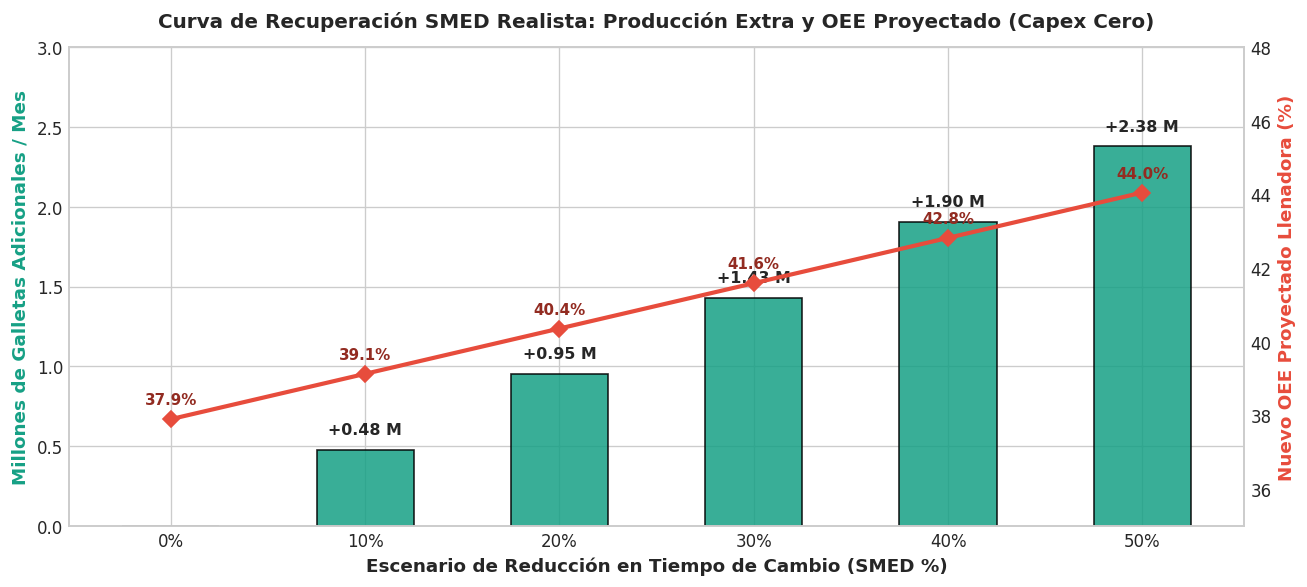

In [10]:
fig, ax1 = plt.subplots(figsize=(11, 5))

# Gráfico de barras: Galletas adicionales mensuales
bars = ax1.bar(
    [f"{r}%" for r in sim_df['Reducción_SMED_%']], 
    sim_df['Galletas_Extra_Mes'] / 1e6, 
    color='#16a085', 
    edgecolor='black', 
    alpha=0.85, 
    width=0.5
)
ax1.set_ylabel('Millones de Galletas Adicionales / Mes', color='#16a085', fontsize=11, fontweight='bold')
ax1.set_xlabel('Escenario de Reducción en Tiempo de Cambio (SMED %)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 3.0)

for bar in bars:
    val = bar.get_height()
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., val + 0.08, f"+{val:.2f} M", ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Eje secundario: Nuevo OEE de la máquina
ax2 = ax1.twinx()
ax2.plot([f"{r}%" for r in sim_df['Reducción_SMED_%']], sim_df['Nuevo_OEE_Llenadora_%'], color='#e74c3c', marker='D', linewidth=2.5, markersize=7)
ax2.set_ylabel('Nuevo OEE Proyectado Llenadora (%)', color='#e74c3c', fontsize=11, fontweight='bold')
ax2.set_ylim(35, 48)
ax2.grid(False)

for i, txt in enumerate(sim_df['Nuevo_OEE_Llenadora_%']):
    ax2.annotate(f"{txt:.1f}%", (i, sim_df['Nuevo_OEE_Llenadora_%'][i] + 0.4), ha='center', fontsize=9, fontweight='bold', color='#922b21')

plt.title('Curva de Recuperación SMED Realista: Producción Extra y OEE Proyectado (Capex Cero)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 💡 7. Conclusiones y Propuesta Estratégica Dual (SMED + TPM)

1. **Rigor Metodológico y Auditoría:**
   - La auditoría descubrió que **350.1 horas** dentro de `CC` no eran limpiezas, sino **55 averías mecánicas y paradas mayores** (incluyendo el Horno parado 60 horas y la Mezcladora 44 horas).
   - La Llenadora sufrió además una **parada no tipificada de 132.5 horas (Categoría 0)** que mantuvo la máquina apagada durante casi una semana completa (19 al 25 de julio).
2. **Estrategia Dual de Operaciones (Double-Track Roadmap):**
   - **Track A (Lean SMED - Capex Cero):** Enfocado en las **123.5 horas de cambios rutinarios** de la Llenadora. Una reducción del 40% libera **49.4 horas/mes**, generando **+1.90 millones de galletas al mes (+22.8 millones al año)** y elevando el OEE de la Llenadora de 37.9% a 42.8%.
   - **Track B (TPM & Mantenimiento Predictivo):** Enfocado en erradicar las **58.98 horas de averías encubiertas** y la **parada de 132.5 horas** de la Llenadora mediante inspección autónoma de dosificadores, trazabilidad térmica de cremas y gestión de repuestos críticos.

In [11]:
# Exportar tablas analíticas normalizadas para el Dashboard Web
loss_summary.to_csv(os.path.join(PROCESSED_DIR, 'loss_tree_summary.csv'), index=False)
pareto_smed_m.to_csv(os.path.join(PROCESSED_DIR, 'pareto_machines_smed_routine.csv'), index=False)
pareto_bk_m.to_csv(os.path.join(PROCESSED_DIR, 'pareto_machines_breakdowns.csv'), index=False)
pareto_p.to_csv(os.path.join(PROCESSED_DIR, 'pareto_products_cc.csv'), index=False)
speed_diag.to_csv(os.path.join(PROCESSED_DIR, 'speed_analysis_bottleneck.csv'), index=False)
sim_df.to_csv(os.path.join(PROCESSED_DIR, 'smed_simulation_scenarios.csv'), index=False)

print("✅ Archivo exportado: loss_tree_summary.csv")
print("✅ Archivo exportado: pareto_machines_smed_routine.csv")
print("✅ Archivo exportado: pareto_machines_breakdowns.csv")
print("✅ Archivo exportado: pareto_products_cc.csv")
print("✅ Archivo exportado: speed_analysis_bottleneck.csv")
print("✅ Archivo exportado: smed_simulation_scenarios.csv")

✅ Archivo exportado: loss_tree_summary.csv
✅ Archivo exportado: pareto_machines_smed_routine.csv
✅ Archivo exportado: pareto_machines_breakdowns.csv
✅ Archivo exportado: pareto_products_cc.csv
✅ Archivo exportado: speed_analysis_bottleneck.csv
✅ Archivo exportado: smed_simulation_scenarios.csv
